# Leiden cluster annotation from SCVI

In [ ]:
library_load <- suppressMessages(
    
    list(
        
        # Seurat 
        library(Seurat), 
        
        # Data 
        library(tidyverse), 
        library(data.table), 
        
        # Plotting 
        library(patchwork), 
        
        # Pyhton compatibility
        library(reticulate)
        
    )
    
)

Warning message:
“package ‘ggplot2’ was built under R version 4.1.3”
Warning message:
“package ‘tibble’ was built under R version 4.1.3”
Warning message:
“package ‘tidyr’ was built under R version 4.1.3”
Warning message:
“package ‘readr’ was built under R version 4.1.3”


In [ ]:
options(warn=-1)

In [ ]:
random_seed <- 42
set.seed(random_seed)

In [ ]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20220623HSCT")

In [ ]:
# Source files
source("plotting_global.R")
source("bin/seurat_qc.R")
source("bin/dp_feature.R")

# Parameter and data import 

In [ ]:
# Files 
qc_rds_file <- "data/object/qc.rds"
pp_rds_file <- "data/object/pp.rds"

# Meta data 
meta <- read.csv("data/object/components/meta.csv", row.names=1)

# UMAP 
umap <- read.csv("data/object/components/umap.csv", row.names=1)
colnames(umap) <- c("UMAP_1", "UMAP_2")

# Plotting Theme
ggplot2::theme_set(theme_global_set(size_select=1)) # From project global source()

# Import Seurat object

In [ ]:
so <- readRDS(qc_rds_file)

In [41]:
so <- AddMetaData(so, meta)
so[["umap"]] <- CreateDimReducObject(embeddings=as.matrix(umap), key="UMAP_")

# Cell type annotation by leiden cluster

In [187]:
cell_type_leiden <- data.frame(

    leiden=0:29, 
    
    cell_type_leiden=c(
    
        "Mac", # 0
        "Mono-1", # 1
        "TC-1", # 2
        "Fibro-1", # 3
        "NK", # 4
        "Fibro-2", # 5
        "TC-2", # 6
        "TC-3", # 7
        "Fibro-3", # 8
        "Mono-2", # 9
        "Kc-1", # 10
        "Fibro-4", # 11
        "TC-4", # 12
        "TC-5", # 13
        "vEC", # 14
        "TC_NK", # 15
        "Pc", # 16
        "Kc-2", # 17
        "Mono-3", # 18
        "DC-1", # 19
        "ILCs", # 20
        "Fibro-5", # 21
        "BC", # 22
        "Mlc", # 23
        "pDC", # 24
        "HSC", # 25
        "lEC", # 26
        "Mono-4", # 27
        "DC-2", # 28
        "Mast cell"  # 29
    
    )

)

In [188]:
cell_type_leiden_order <- c(

    paste0("HSC"), 
    paste0("Mast cell"), 
    paste0("Mono-", 1:4), 
    paste0("Mac"),
    paste0("DC-", 1:2), 
    paste0("pDC"), 
    paste0("BC"), 
    paste0("ILCs"), 
    paste0("NK"), 
    paste0("TC_NK"), 
    paste0("TC-", 1:5), 
    paste0("Mlc"),
    paste0("lEC"), 
    paste0("vEC"), 
    paste0("Pc"), 
    paste0("Fibro-", 1:5), 
    paste0("Kc-", 1:2)

)

In [189]:
cell_type_leiden <- dplyr::left_join(so@meta.data[, c("cell_id", "leiden"), drop=FALSE], cell_type_leiden, by="leiden") %>% column_to_rownames(var="cell_id") %>% dplyr::select(-leiden)

In [190]:
so <- AddMetaData(so, cell_type_leiden)
so$cell_type_leiden <- factor(so$cell_type_leiden, levels=rev(cell_type_leiden_order))

# Cell type marker 

In [226]:
cell_type_marker <- data.frame(
    
    genes=c(
        
        "MKI67", # Proliferation
        "PTPRC", # Immune cells
        "CD34", # HSC
        "KIT", "MS4A2", # Mast cells (+ Melanocytes)
        "CD14", # Monocytes
        "CD68","CD163", # Macrophages
        "CD1C", # DC
        "IL3RA", # pDC
        "MS4A1", # B cells
        "NCAM1", # NK
        "CD3E","CD4","CD8A", # T cells
        "MLANA",# Melanocytes
        "PECAM1","LYVE1","VWF", # Endothelial cells (Lyve1 = lymphoid, VWF = vascular)
        "RERGL", # Pericytes
        "THY1", # Fibroblasts
        "KRT1","KRT15" # Keratinocytes
        
    ), 
    
    cell_type=c(
        
        rep("Proliferation", 1), 
        rep("Immune cells", 1), 
        rep("HSC", 1), 
        rep("Mast cells", 2), 
        rep("Monocytes", 1), 
        rep("Macrophages", 2), 
        rep("DC", 1), 
        rep("pDC", 1), 
        rep("B cells", 1), 
        rep("NK", 1), 
        rep("T cells", 3), 
        rep("Melanocytes", 1), 
        rep("Endothelial cells", 3), 
        rep("Pericytes", 1), 
        rep("Fibroblasts", 1), 
        rep("Keratinocytes", 2)
    )

)

# Plot marker genes 

`summarise()` has grouped output by 'cell_type_leiden'. You can override using
the `.groups` argument.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


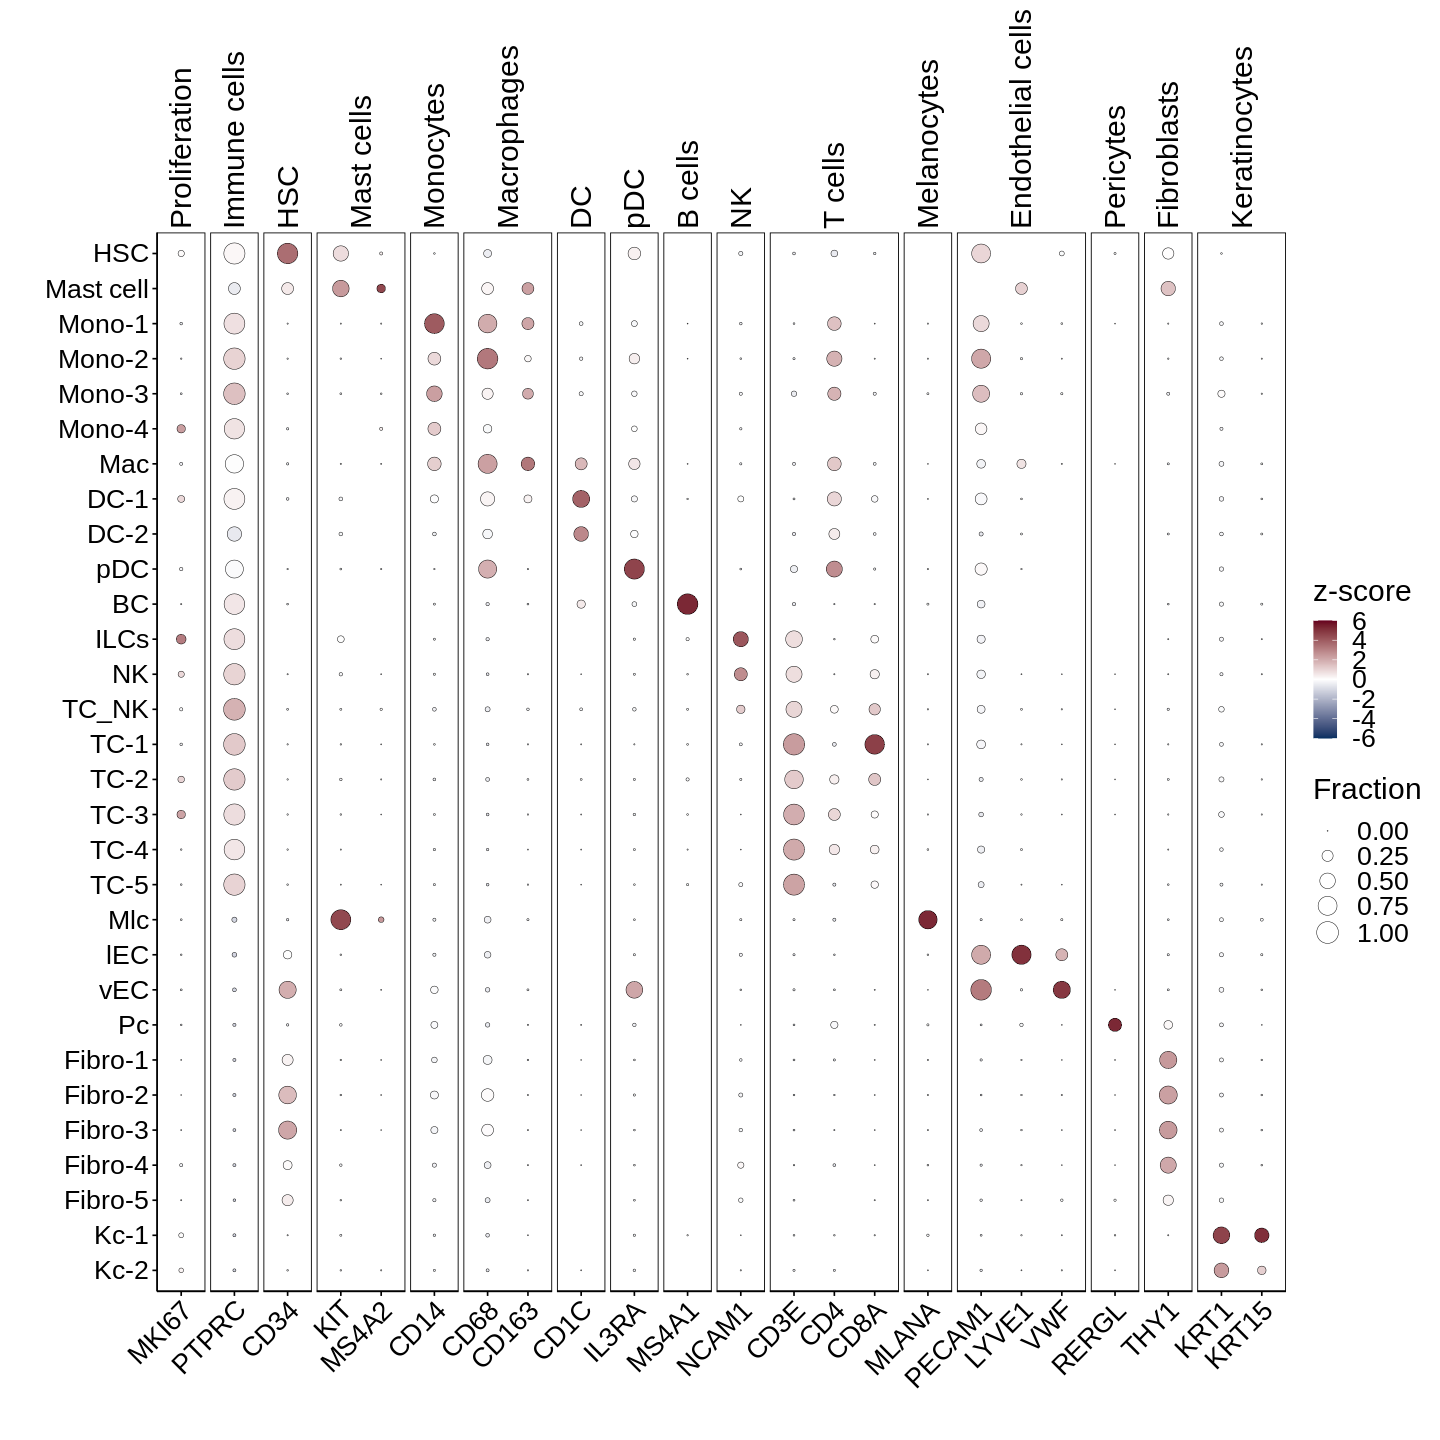

In [227]:
options(repr.plot.width=12, repr.plot.height=12)

dp_feature(so, cell_type_marker$genes, split=cell_type_marker$cell_type, split_order=unique(cell_type_marker$cell_type), group_by="cell_type_leiden", group_by_order=NULL, title=NULL, scale=TRUE, assay="RNA", range_min=0, range_max=6) + 
    theme(
        axis.text.y=element_text(hjust=1,vjust=0.5), 
        strip.text.x=element_text(angle=90, hjust=0, vjust=0.5), 
        strip.background=element_rect(fill="transparent", color=NA), 
        panel.border=element_rect(fill=NA, color="black")
    )

# UMAP

In [235]:
so$cell_type_leiden <- factor(so$cell_type_leiden, levels=cell_type_leiden_order)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


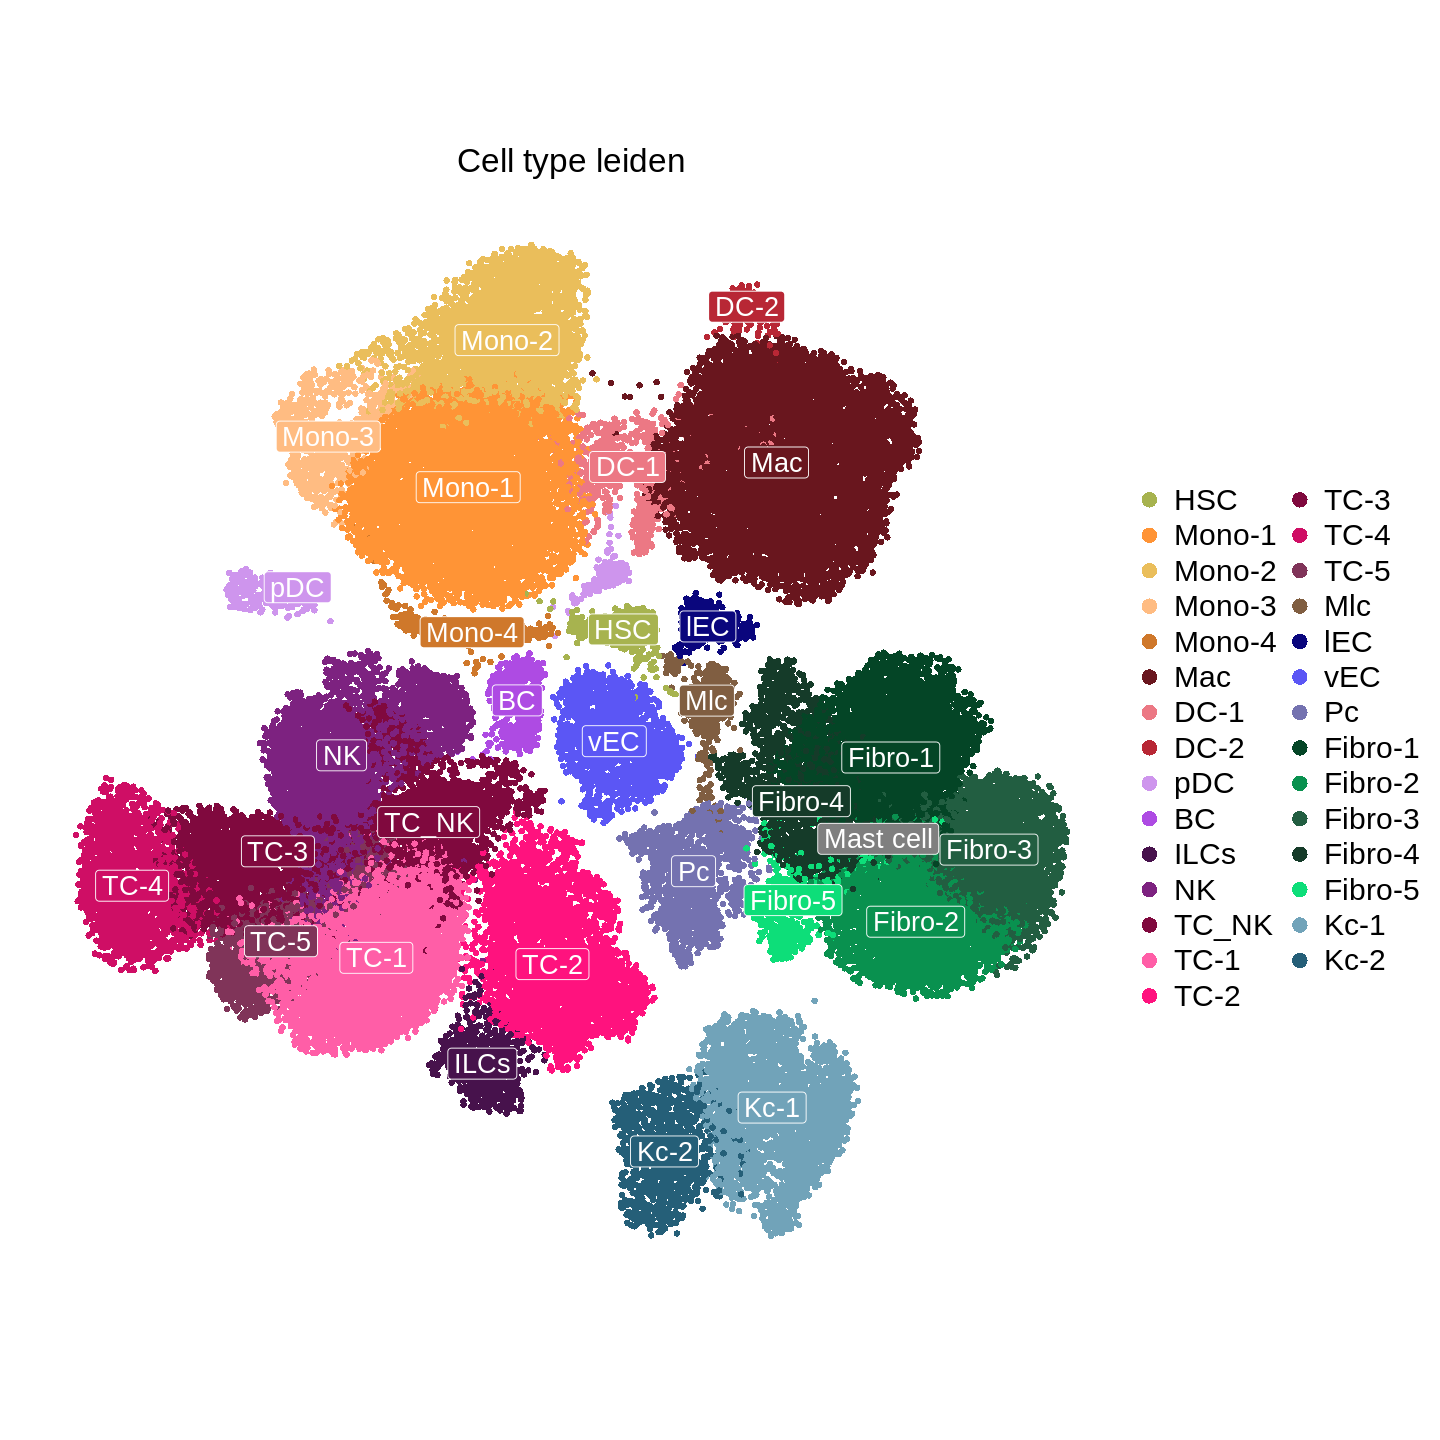

In [236]:
options(repr.plot.width=12, repr.plot.height=12)

dplot_1 <- dplot(so, reduction="umap", group_by="cell_type_leiden", alpha=1, pt_size=1.5, label=TRUE, label_size=16, label_box=TRUE) + ggtitle("Cell type leiden") + scale_color_manual(values=color$cell_type_leiden, na.value="grey50") + scale_fill_manual(values=color$cell_type_leiden, na.value="grey50") 

dplot_1 

# Save results

In [238]:
write.csv(cell_type_leiden, "result/annotation/cell_type_leiden.csv")
write.csv(so@meta.data, "data/object/components/meta.csv")

In [239]:
saveRDS(so, pp_rds_file)

# Session info

In [240]:
sessionInfo()

R version 4.1.0 (2021-05-18)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.5 (Ootpa)

Matrix products: default
BLAS/LAPACK: /nobackup/peer/fdeckert/miniconda3/envs/r.4.1.0-FD20220623HSCT/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] RColorBrewer_1.1-3 viridis_0.6.3      viridisLite_0.4.2  reticulate_1.30   
 [5] patchwork_1.1.2    data.table_1.14.8  lubridate_1.9.2    forcats_1.0.0     
 [9] stringr_1.5.0      dplyr_1.1.2        purrr_1.0.1        readr_2.1.4       
[13] tidyr_1.3.0